# LangGraph agent

The linear pipeline (nb 04) always retrieves once, then answers once. Here the LLM drives a **graph** instead: gate off-topic questions, search when useful, loop on the results, stop with a cited answer.

```
START ─▶ intent_router ──off-topic──▶ END
              │ on-topic
              ▼
          agent_node ──FinalResponse──▶ END
            ▲     │ search_recipes
            └─ tool_node ◀┘
```

In [16]:
import sys, json
from operator import add
from pathlib import Path
from typing import Annotated, Any

ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dotenv import load_dotenv
load_dotenv(ROOT / ".env")

import instructor
from pydantic import BaseModel, Field
from IPython.display import Image, display
from langchain_core.messages import AIMessage, HumanMessage, convert_to_openai_messages
from langchain_core.tools import tool
from langchain_core.utils.function_calling import convert_to_openai_tool
from langgraph.graph import END, START, StateGraph
from langgraph.prebuilt import ToolNode
from langfuse.openai import openai  # drop-in: auto-traces every call

from ragu.retrieval import retrieve_data, rerank, format_blocks, fetch_recipes_by_ids
from ragu.prompt_loader import render_prompt

PROMPTS_DIR = ROOT / "ragu" / "prompts"

## 1. Tools

`search_recipes` runs the real hybrid retrieval. `FinalResponse` is a *fake* tool: calling it is how the agent stops and cites the recipes it actually used.

In [17]:
@tool
def search_recipes(query: str, top_k: int = 5) -> str:
    """Hybrid recipe search. Keep numeric limits in the query text
    ("under 600 calories", "30 minutes") -- they become hard filters."""
    retrieved = retrieve_data(query, k=20)
    recipes = rerank(query, retrieved["recipes"], top_n=top_k)
    if not recipes:
        return "No recipes found. Try rephrasing or broadening the query."
    text = "\n\n".join(format_blocks(recipes))
    if retrieved["filter_relaxed"]:
        text = "Note: no recipe matched the numbers; showing closest matches.\n\n" + text
    return text


class RAGUsedContext(BaseModel):
    id: int = Field(description="Recipe id, as returned by the search tool")
    name: str = Field(description="Recipe name, as returned by the search tool")


class FinalResponse(BaseModel):
    answer: str = Field(description="Answer to the user, in natural language")
    references: list[RAGUsedContext] = Field(
        description="Only the recipes actually used in the answer."
    )

## 2. State

One object flows through every node. `messages` uses an `add` reducer, so nodes **append** to the conversation instead of overwriting it.

In [18]:
class State(BaseModel):
    messages: Annotated[list[Any], add] = []
    question_relevant: bool = True
    iteration: int = 0
    answer: str = ""
    final_answer: bool = False
    references: list[RAGUsedContext] = []

## 3. Agent node + router

The ReAct brain. `tool_choice="required"` forces a tool call every turn: `search_recipes` to loop, `FinalResponse` to finish. `tool_router` reads state and picks the next hop (loop capped at 2).

In [19]:
AGENT_TOOLS = [convert_to_openai_tool(search_recipes), convert_to_openai_tool(FinalResponse)]


def agent_node(state: State) -> dict:
    response = openai.chat.completions.create(
        model="gpt-5.4-mini",
        messages=[
            {"role": "system", "content": render_prompt(PROMPTS_DIR, "agent_prompt")},
            *convert_to_openai_messages(state.messages),
        ],
        tools=AGENT_TOOLS,
        tool_choice="required",
        reasoning_effort="none",
        name="agent_llm",
    )
    msg = response.choices[0].message
    tool_calls = [
        {"name": tc.function.name, "args": json.loads(tc.function.arguments),
         "id": tc.id, "type": "tool_call"}
        for tc in (msg.tool_calls or [])
    ]

    final = next((tc for tc in tool_calls if tc["name"] == "FinalResponse"), None)
    return {
        "messages": [AIMessage(content=msg.content or "", tool_calls=tool_calls)],
        "iteration": state.iteration + 1,
        "final_answer": final is not None,
        "answer": final["args"]["answer"] if final else "",
        "references": final["args"]["references"] if final else [],
    }


def tool_router(state: State) -> str:
    if state.final_answer or state.iteration > 2:
        return "end"
    return "tools" if state.messages[-1].tool_calls else "end"

## 4. Intent router

A cheap first gate (nano model, structured output via instructor): off-topic → reply and stop, without ever searching.

In [20]:
class IntentRouterResponse(BaseModel):
    question_relevant: bool
    answer: str = Field(description="Brief friendly reply when off-topic; empty otherwise.")


intent_client = instructor.from_provider("openai/gpt-5.4-nano", mode=instructor.Mode.RESPONSES_TOOLS)


def intent_router_node(state: State) -> dict:
    r = intent_client.create(
        messages=[
            {"role": "system", "content": render_prompt(PROMPTS_DIR, "intent_router")},
            *convert_to_openai_messages(state.messages),
        ],
        reasoning={"effort": "none"},
        response_model=IntentRouterResponse,
    )
    return {"question_relevant": r.question_relevant, "answer": r.answer}


def route_intent(state: State) -> str:
    return "agent_node" if state.question_relevant else "end"

INFO:instructor.auto_client:Initializing openai provider with model gpt-5.4-nano
INFO:instructor.auto_client:Client initialized


## 5. Build & visualize

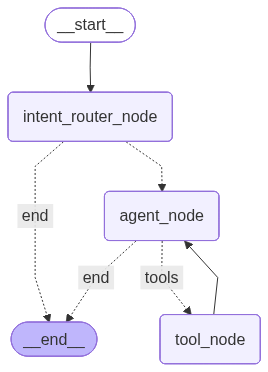

In [21]:
graph = (
    StateGraph(State)
    .add_node("intent_router_node", intent_router_node)
    .add_node("agent_node", agent_node)
    .add_node("tool_node", ToolNode([search_recipes]))
    .add_edge(START, "intent_router_node")
    .add_conditional_edges("intent_router_node", route_intent,
                           {"agent_node": "agent_node", "end": END})
    .add_conditional_edges("agent_node", tool_router,
                           {"tools": "tool_node", "end": END})
    .add_edge("tool_node", "agent_node")
    .compile()
)

display(Image(graph.get_graph().draw_mermaid_png()))

## 6. Run

On-topic loops through search; off-topic short-circuits at the router.

In [22]:
def run(question: str) -> dict:
    # graph.invoke returns only channels a node wrote, so read with .get + defaults:
    # the off-topic path never enters agent_node, so `iteration`/`answer` stay unset.
    state = graph.invoke({"messages": [HumanMessage(content=question)]})
    print(f"relevant={state.get('question_relevant', True)}  iterations={state.get('iteration', 0)}\n")
    print(state.get("answer") or "(no answer)")
    for r in state.get("references", []):
        print(f"  - {r['name']} (id {r['id']})")
    return state


state = run("high-protein dinner under 600 kcal, ready in 30 minutes")

relevant=True  iterations=3

Chicken Avocado Stir Fry is the best match I found: 472 kcal, 49g protein, and ready in 18 minutes. It fits your under-600-kcal, 30-minute target well.

If you want, I can also suggest a couple of close alternatives from the results, but this is the strongest match.
  - Chicken Avocado Stir Fry (id 434676)


In [23]:
run("What's the weather in Milan today?")

relevant=False  iterations=0

I can only help with recipes and what to cook, not the weather. What kind of dish are you looking for today?


{'messages': [HumanMessage(content="What's the weather in Milan today?", additional_kwargs={}, response_metadata={})],
 'question_relevant': False,
 'answer': 'I can only help with recipes and what to cook, not the weather. What kind of dish are you looking for today?'}